# 2D diffusion sample

Sample VAE latents from the trained diffusion model and inspect the relaxed and quantized phase images.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.runtime import load_defaults, load_predictor
from src.modeling.phases import (
    probabilities_to_calibrated_labels,
    probabilities_to_relaxed_labels,
)

## Parameters

In [2]:
RUN_DIR = "run/20260714-050533-017623"
BATCH_SIZE = 1

## Sample

In [3]:
run_dir = Path(RUN_DIR) if RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "diffusion.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_phases = load_defaults(run_dir / "vae.yaml")["num_phases"]
predictor = load_predictor(run_dir, device=device)
vae = predictor.vae

print("run:", run_dir)
print("device:", device)

run: d:\code\microlad\run\20260714-050533-017623
device: cuda


## Check

shape: (1, 1, 64, 64)
phase fraction: [0.3145, 0.1589, 0.5266]


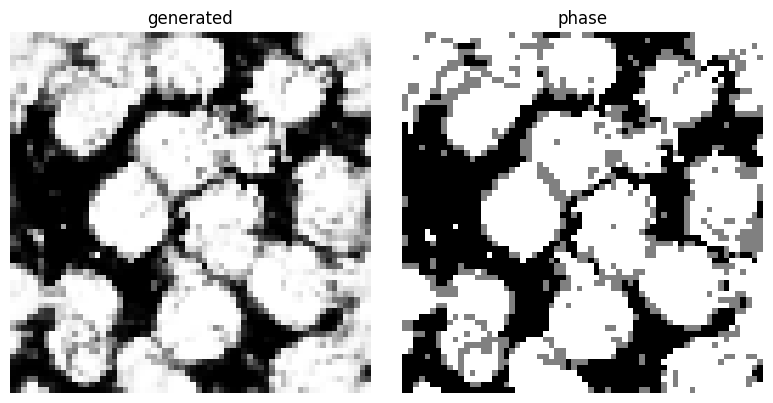

In [4]:
shape = (BATCH_SIZE, int(vae.latent_ch), int(vae.latent_size), int(vae.latent_size))
with torch.no_grad():
    latent = predictor.sampler.sample(shape)
    probabilities = vae.decode_probs(latent).detach().cpu()
generated = probabilities_to_relaxed_labels(probabilities, num_phases)
phase = probabilities_to_calibrated_labels(probabilities, num_phases)
phase_fraction = [(phase == value).float().mean().item() for value in range(num_phases)]
print("shape:", tuple(phase.shape))
print("phase fraction:", [round(value, 4) for value in phase_fraction])

items = [("generated", generated[0, 0], "gray", 0, num_phases - 1), ("phase", phase[0, 0], "gray", 0, num_phases - 1)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
for ax, (title, image, cmap, vmin, vmax) in zip(axes.ravel(), items):
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()